##  Imports

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# from google.colab import drive
# drive.mount('/content/drive')
# for colab

# -----------------------------------------------------------------------------------

## Load Data

In [2]:
def get_data(path:str = "../data/raw/factory_sensor.csv") -> pd.DataFrame:
    df = pd.read_csv(path, engine='pyarrow' )
    return df

df = get_data()
print("data loaded")

data loaded


# -----------------------------------------------------------------------------------

## Basic Explorion

In [3]:
df.head()

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0


In [4]:
df.describe()

,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
count,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,15156.000000,30340.000000,45624.000000,45214.000000,500000.000000
mean,2019.962360,50012.424764,59.997682,9.99114,75.003477,69.456568,64.114159,149.922161,182.257866,5.003128,2.000588,3.000840,452.422338,74.995513,119.917514,39.984794,499.760966,0.602098
std,11.829812,28861.849078,14.986973,4.99953,9.990791,18.847444,23.152998,79.955937,105.552537,2.238043,1.413087,1.730541,288.971269,10.035133,15.017048,9.989653,50.012057,1.203647
min,2000.000000,0.000000,-15.730000,-17.82000,23.650000,0.000000,0.000000,-222.740000,0.000000,0.000000,0.000000,0.000000,0.000000,34.970000,52.680000,-0.160000,296.440000,0.000000
25%,2010.000000,25055.000000,49.890000,6.62000,68.270000,56.540000,48.130000,96.090000,91.000000,3.000000,1.000000,2.000000,200.000000,68.250000,109.820000,33.200000,465.940000,0.000000
50%,2020.000000,49973.000000,60.000000,10.00000,75.000000,70.030000,65.010000,149.950000,182.000000,5.000000,2.000000,3.000000,451.000000,74.950000,119.860000,40.030000,499.770000,0.000000
75%,2030.000000,74995.000000,70.050000,13.36000,81.730000,83.540000,81.840000,203.900000,274.000000,6.000000,3.000000,4.000000,700.000000,81.682500,130.072500,46.750000,533.307500,1.000000
max,2040.000000,100000.000000,127.330000,32.47000,120.700000,100.000000,100.000000,544.200000,365.000000,18.000000,12.000000,13.000000,1133.000000,114.320000,185.380000,80.790000,694.170000,11.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  object 
 1   Machine_Type                500000 non-null  object 
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 13  AI_Supervision

# -----------------------------------------------------------------------------------

## Dropping un-necassry column

In [6]:
df.drop(columns=['Machine_ID'],axis=1,inplace=True)
print("column'Machine_ID'dropped")

column'Machine_ID'dropped


# -----------------------------------------------------------------------------------

## Null values

In [7]:
print(" "*5,"----Null Values count----")
print(df.isnull().sum().sort_values(ascending=False))

      ----Null Values count----
Laser_Intensity               484844
Hydraulic_Pressure_bar        469660
Heat_Index                    454786
Coolant_Flow_L_min            454376
Machine_Type                       0
Vibration_mms                      0
Temperature_C                      0
Operational_Hours                  0
Installation_Year                  0
Sound_dB                           0
Oil_Level_pct                      0
Coolant_Level_pct                  0
Power_Consumption_kW               0
AI_Supervision                     0
Failure_History_Count              0
Maintenance_History_Count          0
Last_Maintenance_Days_Ago          0
Failure_Within_7_Days              0
Remaining_Useful_Life_days         0
Error_Codes_Last_30_Days           0
AI_Override_Events                 0
dtype: int64


## Encode and Fill Nulls

In [8]:
df = pd.get_dummies(df, columns=['Machine_Type'], dtype=int)
df.fillna(0, inplace=True)

In [9]:
df.isna().sum().sum()

np.int64(0)

# -----------------------------------------------------------------------------------

## Correlation with Target

In [10]:
corr_matrix = df.corr()

rul_corr = corr_matrix["Failure_Within_7_Days"].sort_values(ascending=False)
print(rul_corr)

Failure_Within_7_Days                 1.000000
Operational_Hours                     0.396812
Vibration_mms                         0.037124
Temperature_C                         0.026189
Machine_Type_Automated_Screwdriver    0.003145
Machine_Type_Furnace                  0.002288
Failure_History_Count                 0.002033
Machine_Type_CNC_Lathe                0.001790
Machine_Type_Press_Brake              0.001361
Machine_Type_Vision_System            0.001361
Laser_Intensity                       0.001060
Machine_Type_Laser_Cutter             0.001015
Heat_Index                            0.001000
Machine_Type_Conveyor_Belt            0.000917
Machine_Type_Robot_Arm                0.000866
Machine_Type_Hydraulic_Press          0.000619
Machine_Type_CNC_Mill                 0.000551
Machine_Type_Crane                    0.000551
Hydraulic_Pressure_bar                0.000473
Machine_Type_Shuttle_System           0.000424
AI_Supervision                        0.000357
Last_Maintena

# -----------------------------------------------------------------------------------

## Dropping

- Leaky Columns

In [11]:
df.drop(columns=['Remaining_Useful_Life_days','Operational_Hours'],axis=1,inplace=True)
print("leaky columns dropped")

leaky columns dropped


- columns that provides almost zero information about target

In [12]:
df.drop(columns=['AI_Override_Events','AI_Supervision'],axis=1,inplace=True)
print("low correlation columns dropped")

low correlation columns dropped


# -----------------------------------------------------------------------------------

## Target Distribution

- visualized correlation with top 10 features after dropping columns

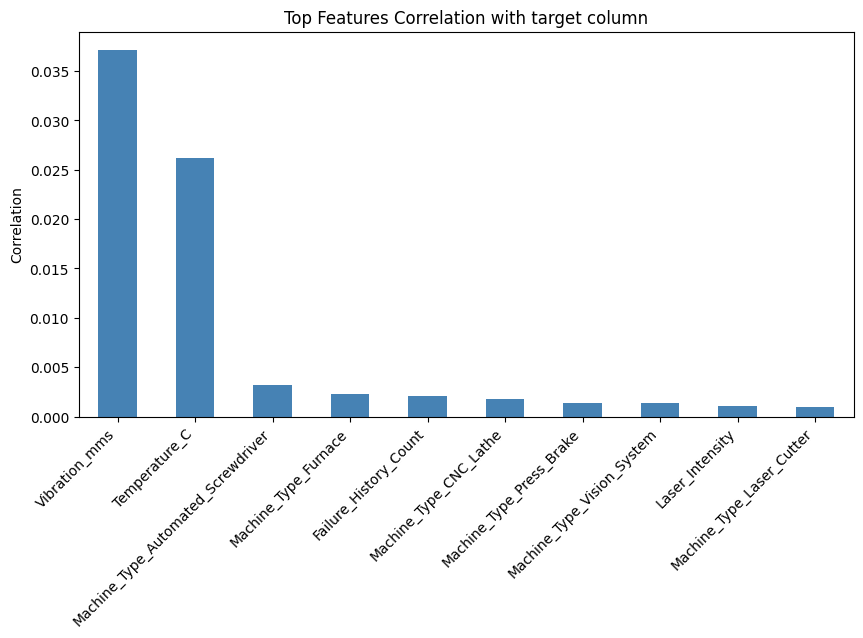

In [13]:
corr_matrix2 = df.corr()
target_corr = corr_matrix2["Failure_Within_7_Days"].sort_values(ascending=False)

top_corr = target_corr[1:11]

plt.figure(figsize=(10, 5))
top_corr.plot(kind='bar', color='steelblue')
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha='right')
plt.title("Top Features Correlation with target column")
plt.show()

- class balance

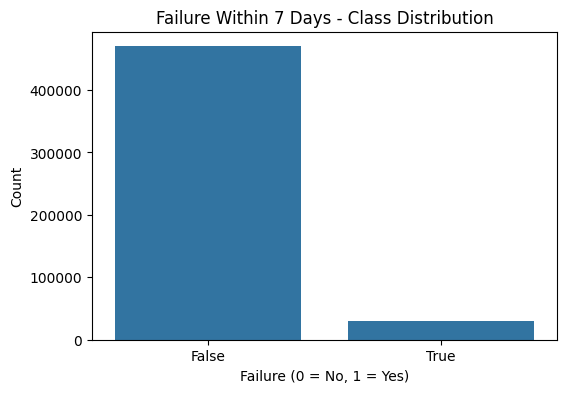

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Failure_Within_7_Days', data=df)
plt.title("Failure Within 7 Days - Class Distribution")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

- class balance

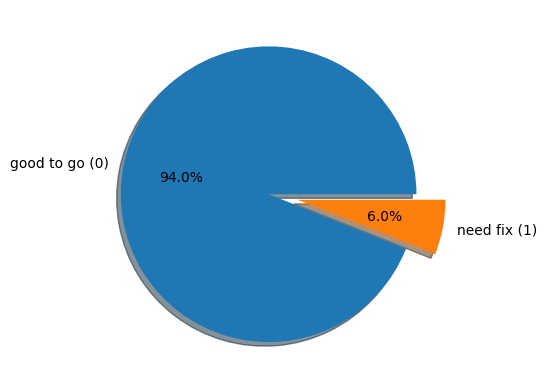

In [15]:
counts = df['Failure_Within_7_Days'].value_counts()

plt.pie(counts,
        labels=['good to go (0)', 'need fix (1)'],
        autopct="%1.1f%%",
        explode=[0,0.2],
        shadow=True)
plt.show()

# -----------------------------------------------------------------------------------

## Turn all values to float

In [16]:
for column in df.columns:
    try:
        df[column]=df[column].astype(float)
    except:
        pass
print("Convert dataType to float success")

Convert dataType to float success


# -----------------------------------------------------------------------------------

### Save Dataset

In [19]:
df.to_csv("../data/processed/factory_sensor_processed.csv",index=False)
print("data Saved")

data Saved


# -----------------------------------------------------------------------------------